<a href="https://colab.research.google.com/github/angelaportillo/AI_IB/blob/main/PIA_CNNonMI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Project- CNN on Medical Images.
##Dataset: Brain MRI Images for Brain Tumor Detection
Hour:N1 Career:IB

###Team members
2028256 Angela Marisa Zapata Portillo

2016872 Marian Roxana Martínez Serrato

2016052 Pablo Ezaú Zapata Cruz

2043428 David Aldebaran Cardona Padilla

2132042 Jennifer Morales Enciso

In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
print("Versión de TensorFlow:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name:
    print("GPU disponible:", device_name)
else:
    print("No se detectó GPU. Activa GPU en: Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador por hardware: GPU")


Versión de TensorFlow: 2.19.0
No se detectó GPU. Activa GPU en: Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador por hardware: GPU


In [ ]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Dataset descargado en:", path)


Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset descargado en: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [ ]:
base_kaggle_path = path

yes_src = os.path.join(base_kaggle_path, "yes")
no_src  = os.path.join(base_kaggle_path, "no")

print(yes_src)
print(no_src)



/kaggle/input/brain-mri-images-for-brain-tumor-detection/yes
/kaggle/input/brain-mri-images-for-brain-tumor-detection/no


In [ ]:
import os
import shutil

# Rutas descargadas con kagglehub
base_kaggle_path = path

yes_src = os.path.join(base_kaggle_path, "yes")
no_src  = os.path.join(base_kaggle_path, "no")

# Nueva ruta para entrenamiento
base_dir = "/content/brain_tumor_data"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

# Crear carpetas destino
os.makedirs(yes_dir, exist_ok=True)
os.makedirs(no_dir, exist_ok=True)

# Copiar imágenes
for f in os.listdir(yes_src):
    shutil.copy(os.path.join(yes_src, f), yes_dir)

for f in os.listdir(no_src):
    shutil.copy(os.path.join(no_src, f), no_dir)

print("Total imágenes en YES:", len(os.listdir(yes_dir)))
print("Total imágenes en NO:", len(os.listdir(no_dir)))


Total imágenes en YES: 155
Total imágenes en NO: 98


In [ ]:
IMG_SIZE = 150
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

validation_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Clases:", train_generator.class_indices)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Clases: {'no': 0, 'yes': 1}


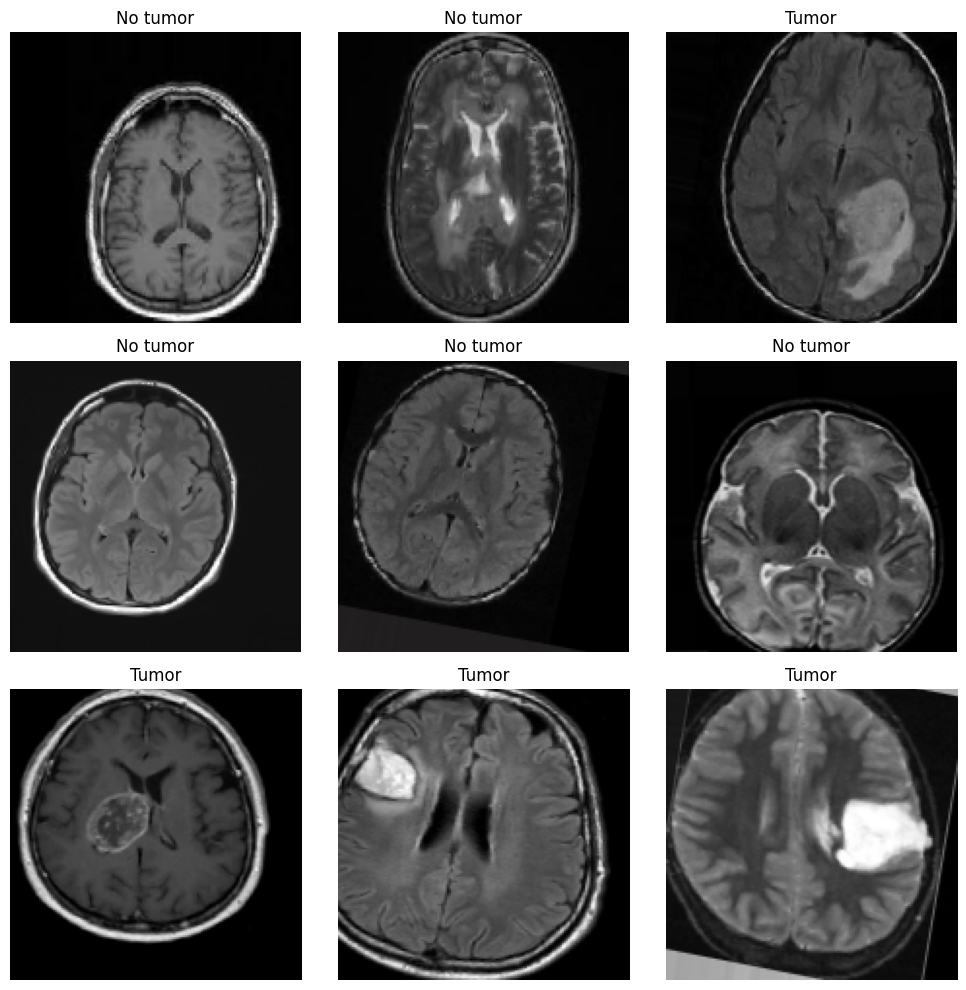

In [ ]:
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i])
    label = 'Tumor' if y_batch[i] == 1 else 'No tumor'
    plt.title(label)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # salida binaria: tumor / no tumor
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_path = 'best_brain_tumor_model.h5'

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)


In [ ]:
EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5763 - loss: 0.6857

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5782 - loss: 0.6826 - val_accuracy: 0.6200 - val_loss: 0.6165
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6524 - loss: 0.6098

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6472 - loss: 0.6146 - val_accuracy: 0.6800 - val_loss: 0.5626
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7315 - loss: 0.5927

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7281 - loss: 0.5955 - val_accuracy: 0.7400 - val_loss: 0.5558
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7386 - loss: 0.6117

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7398 - loss: 0.6092 - val_accuracy: 0.7800 - val_loss: 0.5357
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7612 - loss: 0.5612 - val_accuracy: 0.7600 - val_loss: 0.5525
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7414 - loss: 0.5532 - val_accuracy: 0.7400 - val_loss: 0.5273
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7611 - loss: 0.5201 - val_accuracy: 0.7400 - val_loss: 0.5772
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7310 - loss: 0.5381 - val_accuracy: 0.7400 - val_loss: 0.5557
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7473 - loss: 0.5504 - val_accuracy: 0.7400 - val_loss: 0.5477
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6942 - loss: 0.6074 - val_accuracy: 0.7400 - val_loss: 0.5204
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8056 - loss: 0.5530 - val_accuracy: 0.7600 - val_loss: 0.5442
Epoch 12/20
7/7 ━

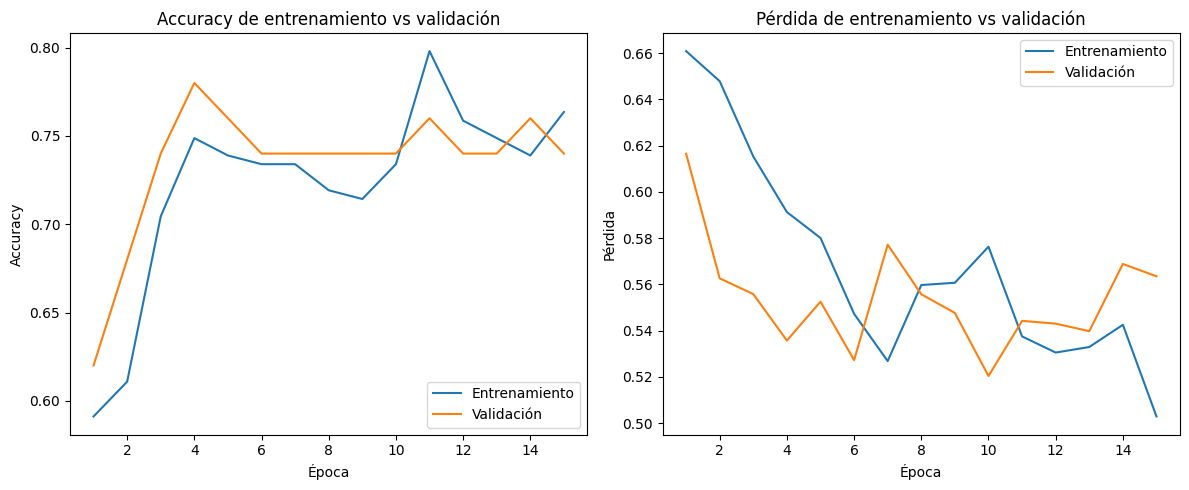

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy de entrenamiento vs validación')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida de entrenamiento vs validación')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Accuracy en test/validación: {val_acc:.4f}")
print(f"Pérdida en test/validación:  {val_loss:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.7121 - loss: 0.5616
Accuracy en test/validación: 0.7400
Pérdida en test/validación:  0.5204


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


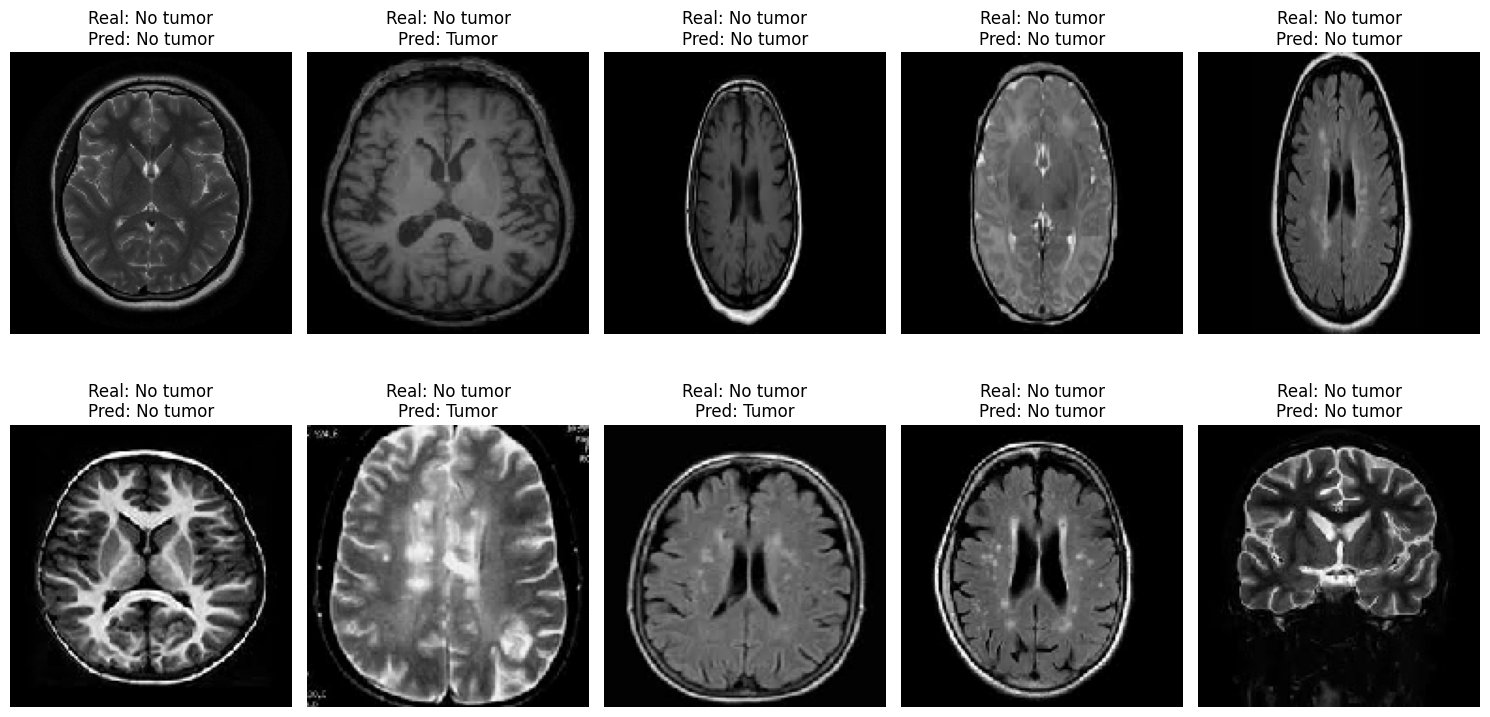

In [ ]:
# Obtenemos un batch del generador de validación
x_val, y_val_true = next(validation_generator)  # batch_size imágenes

# Hacemos predicciones
y_val_pred = model.predict(x_val)
y_val_pred_labels = (y_val_pred > 0.5).astype(int).reshape(-1)

class_indices = validation_generator.class_indices
idx_to_class = {v:k for k, v in class_indices.items()}

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_val[i])
    true_label = 'Tumor' if y_val_true[i] == 1 else 'No tumor'
    pred_label = 'Tumor' if y_val_pred_labels[i] == 1 else 'No tumor'
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()
